In [ ]:
%pip install matplotlib requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


                cpi  inflation_yoy  inflation_mom  inflation_acceleration  \
DATE                                                                        
2025-11-01  325.063       2.988300       0.252278               -0.034272   
2025-12-01  326.031       3.002262       0.297788                0.013962   
2026-01-01  326.588       2.828680       0.170843               -0.173582   
2026-02-01  327.460       2.664589       0.267003               -0.164091   
2026-03-01  330.293       3.320206       0.865144                0.655616   

            mom_vol_12m  
DATE                     
2025-11-01     0.109045  
2025-12-01     0.109551  
2026-01-01     0.107344  
2026-02-01     0.089420  
2026-03-01     0.206870  


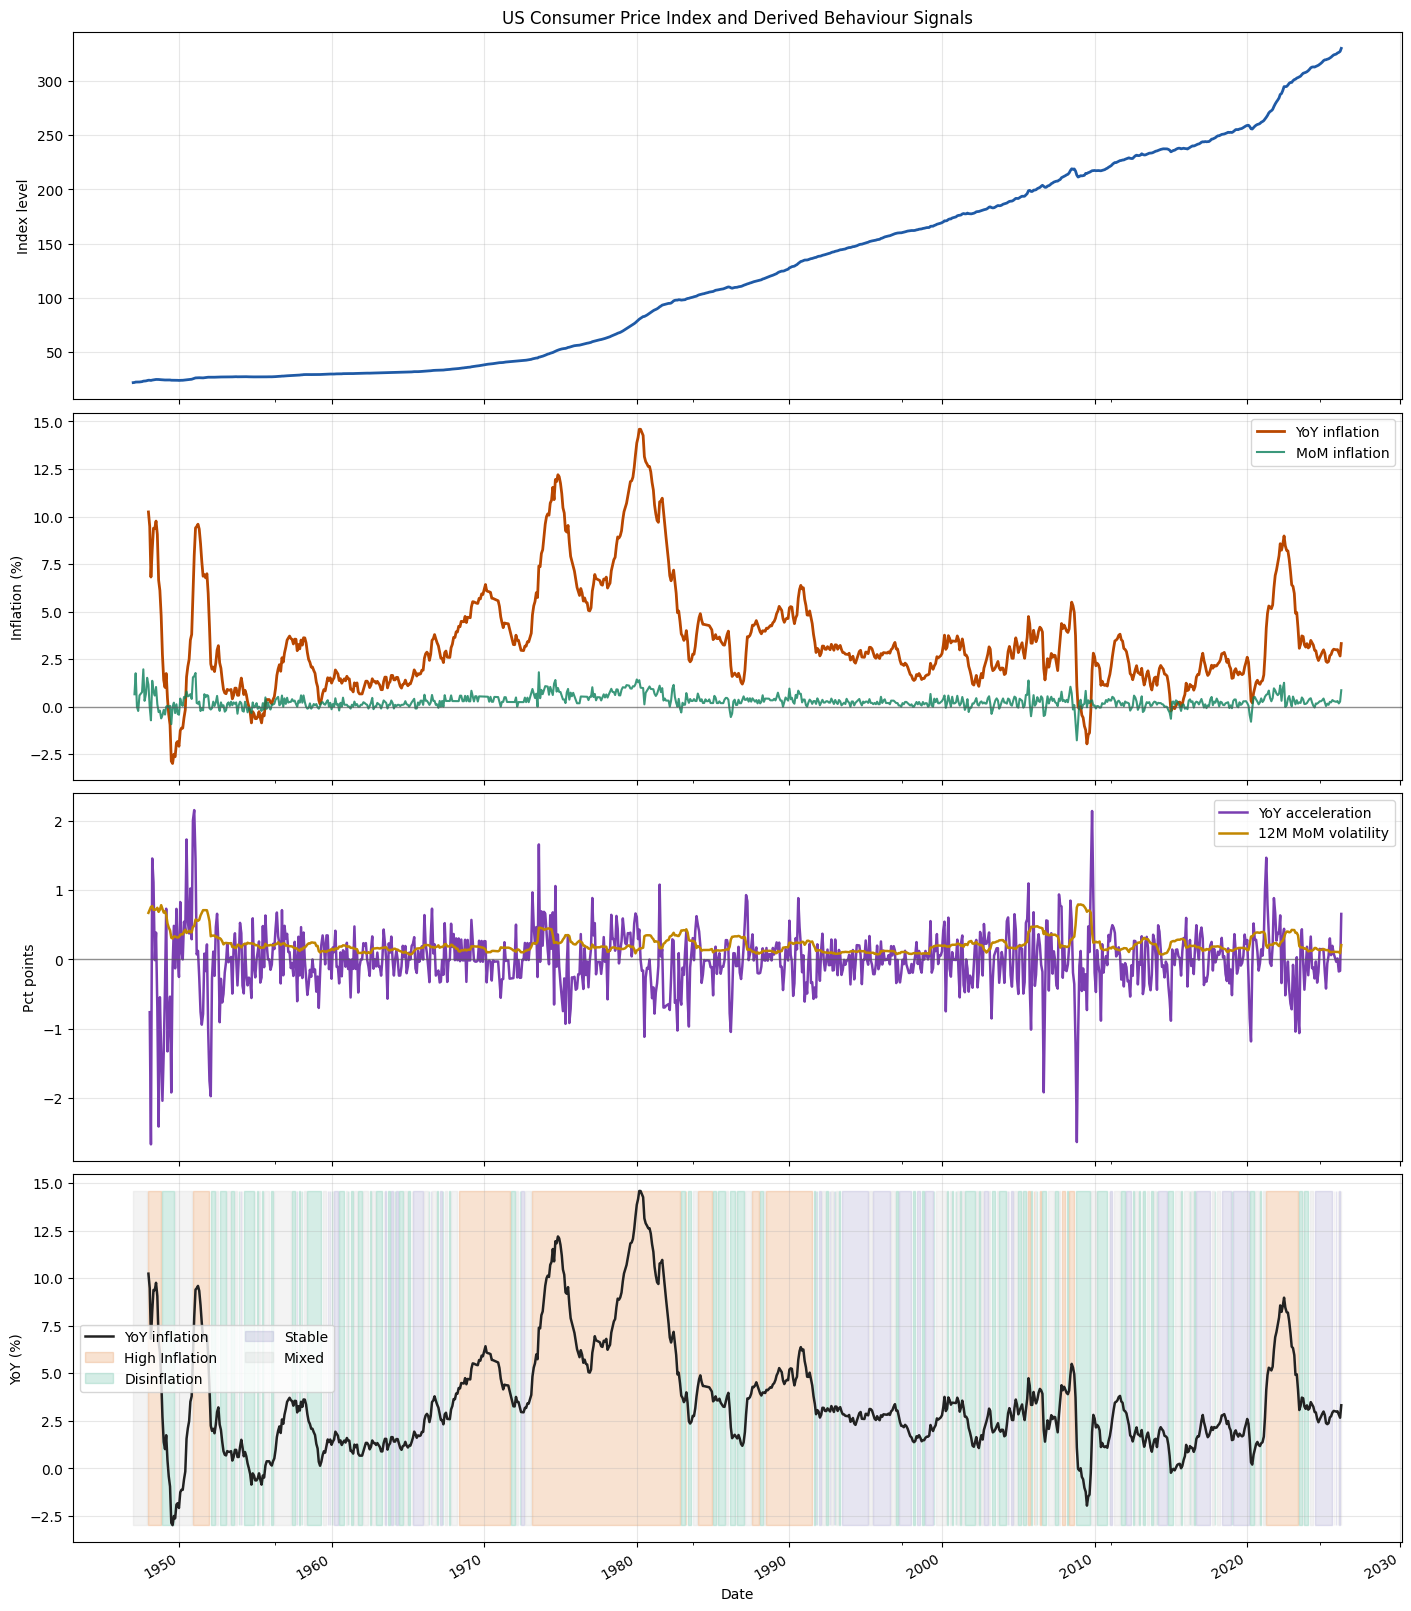

In [18]:
import io

import matplotlib.pyplot as plt
import pandas as pd
import requests

series_id = "CPIAUCSL"
url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

response = requests.get(url, timeout=30)
response.raise_for_status()

cpi_data = pd.read_csv(io.StringIO(response.text))
date_column = "DATE" if "DATE" in cpi_data.columns else "observation_date"
value_columns = [column for column in cpi_data.columns if column != date_column]

if date_column not in cpi_data.columns or len(value_columns) != 1:
    raise ValueError(f"Unexpected columns returned by FRED: {list(cpi_data.columns)}")

value_column = value_columns[0]
cpi_data[date_column] = pd.to_datetime(cpi_data[date_column])
cpi_data[value_column] = pd.to_numeric(cpi_data[value_column], errors="coerce")

analysis = (
    cpi_data.rename(columns={value_column: "cpi"})
    .dropna(subset=["cpi"])
    .set_index(date_column)
    .sort_index()
)
analysis.index.name = "DATE"
analysis["inflation_yoy"] = analysis["cpi"].pct_change(12) * 100
analysis["inflation_mom"] = analysis["cpi"].pct_change() * 100
analysis["inflation_acceleration"] = analysis["inflation_yoy"].diff()
analysis["mom_vol_12m"] = analysis["inflation_mom"].rolling(12).std()
analysis["regime"] = "mixed"
analysis.loc[analysis["inflation_yoy"] > 4, "regime"] = "high inflation"
analysis.loc[
    (analysis["inflation_yoy"] <= 4)
    & (analysis["inflation_yoy"].diff().rolling(3).mean() < 0),
    "regime",
] = "disinflation"
analysis.loc[
    analysis["inflation_yoy"].between(1.5, 3.0)
    & (analysis["mom_vol_12m"] < analysis["mom_vol_12m"].median()),
    "regime",
] = "stable"

print(analysis[["cpi", "inflation_yoy", "inflation_mom", "inflation_acceleration", "mom_vol_12m"]].tail())

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, constrained_layout=True)

analysis["cpi"].plot(ax=axes[0], color="#1f5aa6", lw=2)
axes[0].set_title("US Consumer Price Index and Derived Behaviour Signals")
axes[0].set_ylabel("Index level")
axes[0].grid(True, alpha=0.3)

analysis["inflation_yoy"].plot(ax=axes[1], color="#b94700", lw=2, label="YoY inflation")
analysis["inflation_mom"].plot(ax=axes[1], color="#0a7f5a", lw=1.5, alpha=0.8, label="MoM inflation")
axes[1].axhline(0, color="#555555", lw=1, alpha=0.6)
axes[1].set_ylabel("Inflation (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

analysis["inflation_acceleration"].plot(ax=axes[2], color="#7a3eb1", lw=1.8, label="YoY acceleration")
analysis["mom_vol_12m"].plot(ax=axes[2], color="#c28700", lw=1.8, label="12M MoM volatility")
axes[2].axhline(0, color="#555555", lw=1, alpha=0.6)
axes[2].set_ylabel("Pct points")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

analysis["inflation_yoy"].plot(ax=axes[3], color="#222222", lw=1.8, label="YoY inflation")
regime_colors = {
    "high inflation": "#d95f02",
    "disinflation": "#1b9e77",
    "stable": "#7570b3",
    "mixed": "#bdbdbd",
}

y_min = analysis["inflation_yoy"].min(skipna=True)
y_max = analysis["inflation_yoy"].max(skipna=True)
for regime, color in regime_colors.items():
    axes[3].fill_between(
        analysis.index,
        y_min,
        y_max,
        where=analysis["regime"].eq(regime),
        color=color,
        alpha=0.18,
        label=regime.title(),
    )

axes[3].set_ylabel("YoY (%)")
axes[3].set_xlabel("Date")
axes[3].legend(ncol=2)
axes[3].grid(True, alpha=0.3)

plt.show()